# Credit Risk Dataset: Exploratory Data Analysis

**Authors:** Illian Hashatel, Reda Allab, Issa Ali Adoum  
**Course:** Data Science Software, M2 IRFA, Université Paris 1

---

This notebook covers the exploratory analysis conducted before modeling. The goal is to understand the structure of the data, identify quality issues, and spot the variables most associated with default risk.

**Outline**
1. Loading and first look
2. Missing values
3. Target variable: class imbalance
4. Numerical features: distributions and outliers
5. Categorical features: distributions and default rates
6. Bivariate analysis: numerical features vs default
7. Correlation analysis

## 1. Loading and first look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('credit_risk_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


## 2. Missing values

Two variables contain missing values. Before imputing them, it is worth checking whether missingness itself carries predictive signal: if borrowers with missing data default at a different rate than the rest, the absence of information is informative and should be explicitly modeled.

                   count   pct
person_emp_length    895  2.75
loan_int_rate       3116  9.56


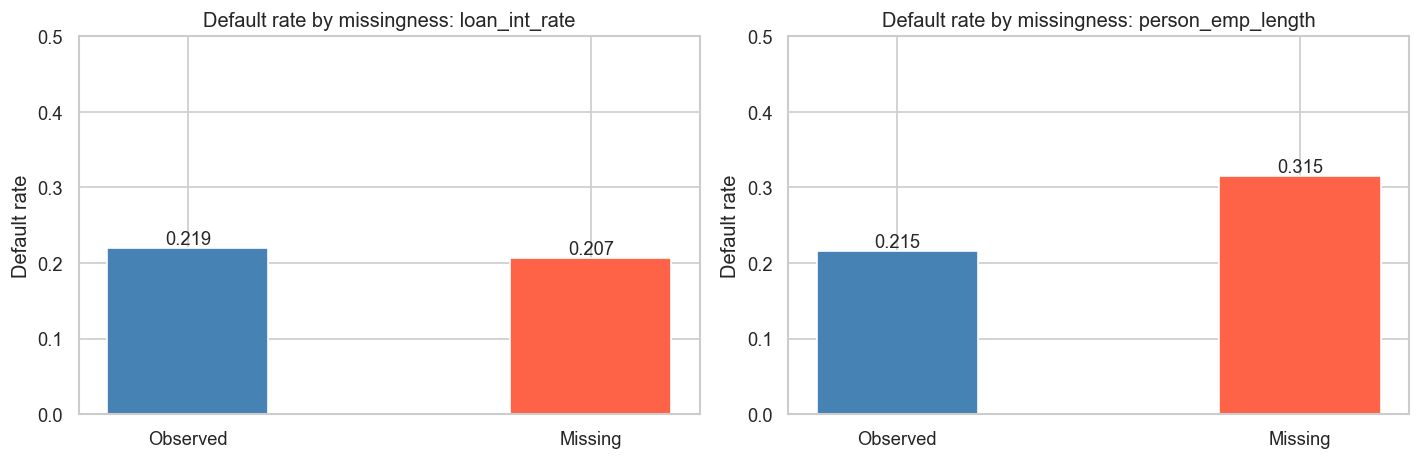

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].to_frame('count')
missing['pct'] = (missing['count'] / len(df) * 100).round(2)
print(missing)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['loan_int_rate', 'person_emp_length']):
    default_rate = df.groupby(df[col].isna())['loan_status'].mean()
    default_rate.index = ['Observed', 'Missing']
    ax.bar(default_rate.index, default_rate.values,
           color=['steelblue', 'tomato'], width=0.4)
    ax.set_title(f'Default rate by missingness: {col}')
    ax.set_ylabel('Default rate')
    ax.set_ylim(0, 0.5)
    for i, v in enumerate(default_rate.values):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

If the two bars differ noticeably for a variable, its missingness is informative and a binary indicator should be added before imputation. This is the approach adopted in the modeling notebook.

## 3. Target variable: class imbalance

With ~22% defaults, the dataset is moderately imbalanced. This rules out accuracy as a reliable evaluation metric and calls for strategies such as balanced class weights during training.

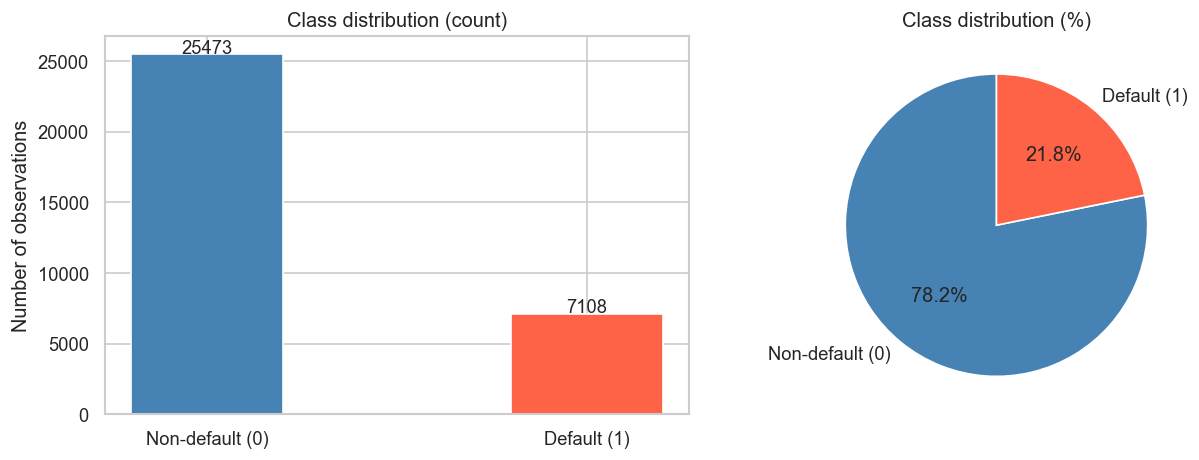

Non-default: 25,473 (78.2%)
Default:     7,108 (21.8%)


In [7]:
counts = df['loan_status'].value_counts()
labels = ['Non-default (0)', 'Default (1)']
colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(labels, counts.values, color=colors, width=0.4)
axes[0].set_title('Class distribution (count)')
axes[0].set_ylabel('Number of observations')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=11)

axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Class distribution (%)')

plt.tight_layout()
plt.show()

print(f'Non-default: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'Default:     {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')

## 4. Numerical features: distributions and outliers

We inspect the distribution of each numerical variable and flag potential outliers. Two variables stand out: `person_age` (max = 144) and `person_emp_length` (max = 123 years), which are clearly data entry errors. These observations will be removed during preprocessing.

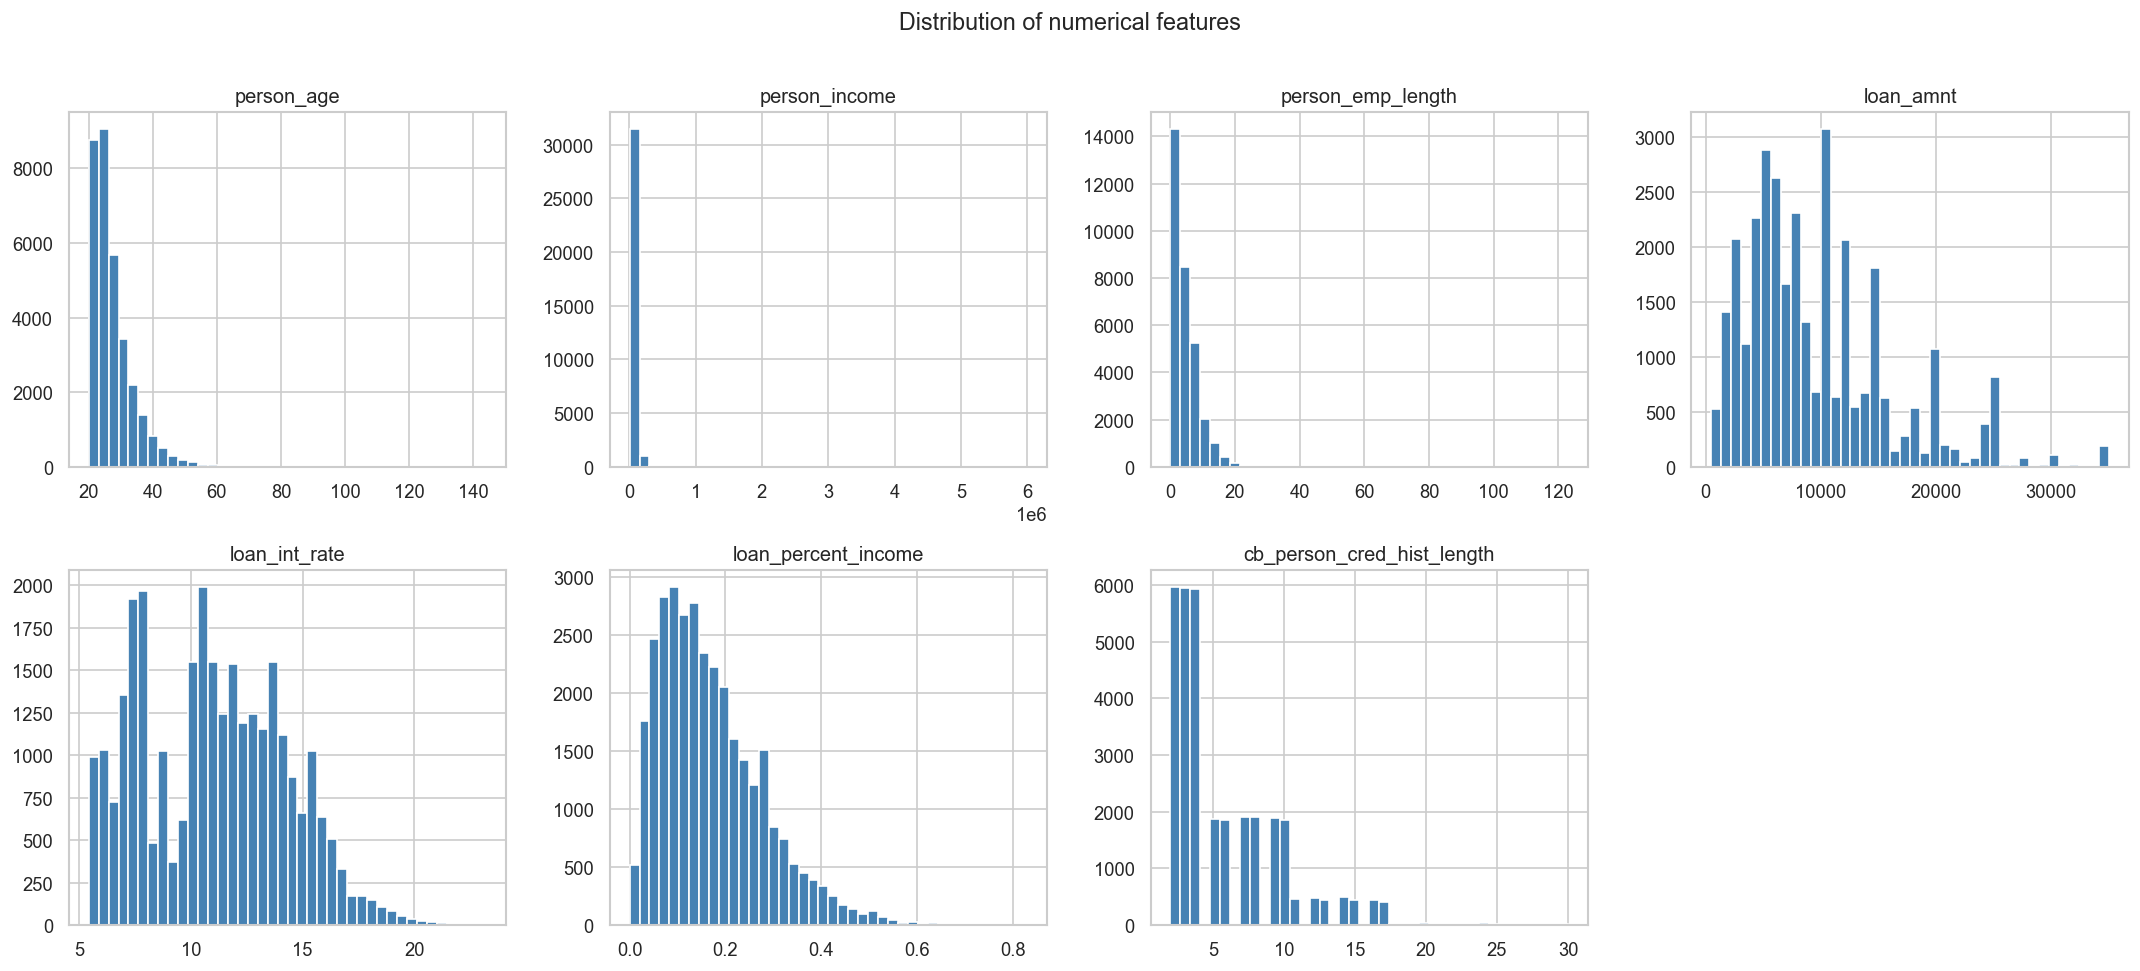

In [8]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Distribution of numerical features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

person_age > 100: 5 observations
person_emp_length > 60: 2 observations
person_income > 500k: 53 observations


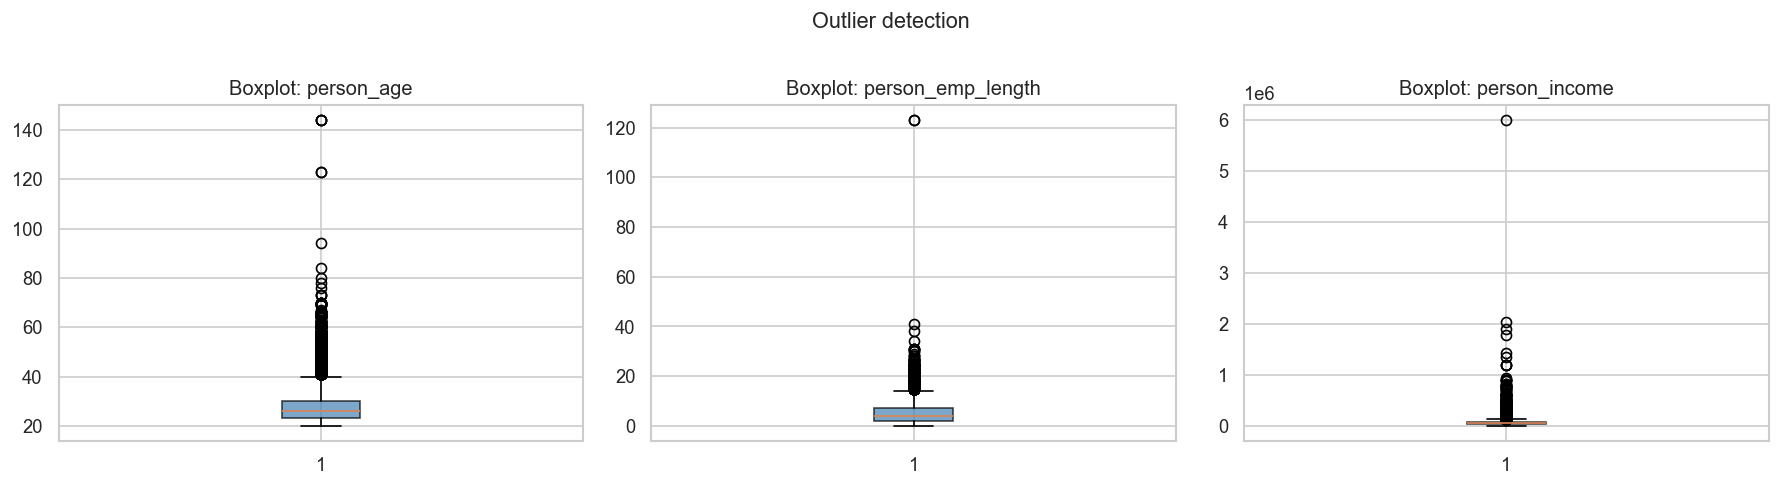

In [9]:
# Outlier check
print('person_age > 100:', (df['person_age'] > 100).sum(), 'observations')
print('person_emp_length > 60:', (df['person_emp_length'] > 60).sum(), 'observations')
print('person_income > 500k:', (df['person_income'] > 500_000).sum(), 'observations')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['person_age', 'person_emp_length', 'person_income']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(f'Boxplot: {col}')

plt.suptitle('Outlier detection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Categorical features: distributions and default rates

For each categorical variable we show both its marginal distribution and the default rate per category. The default rate is the key quantity: a variable is useful for prediction if it separates high-risk and low-risk categories.

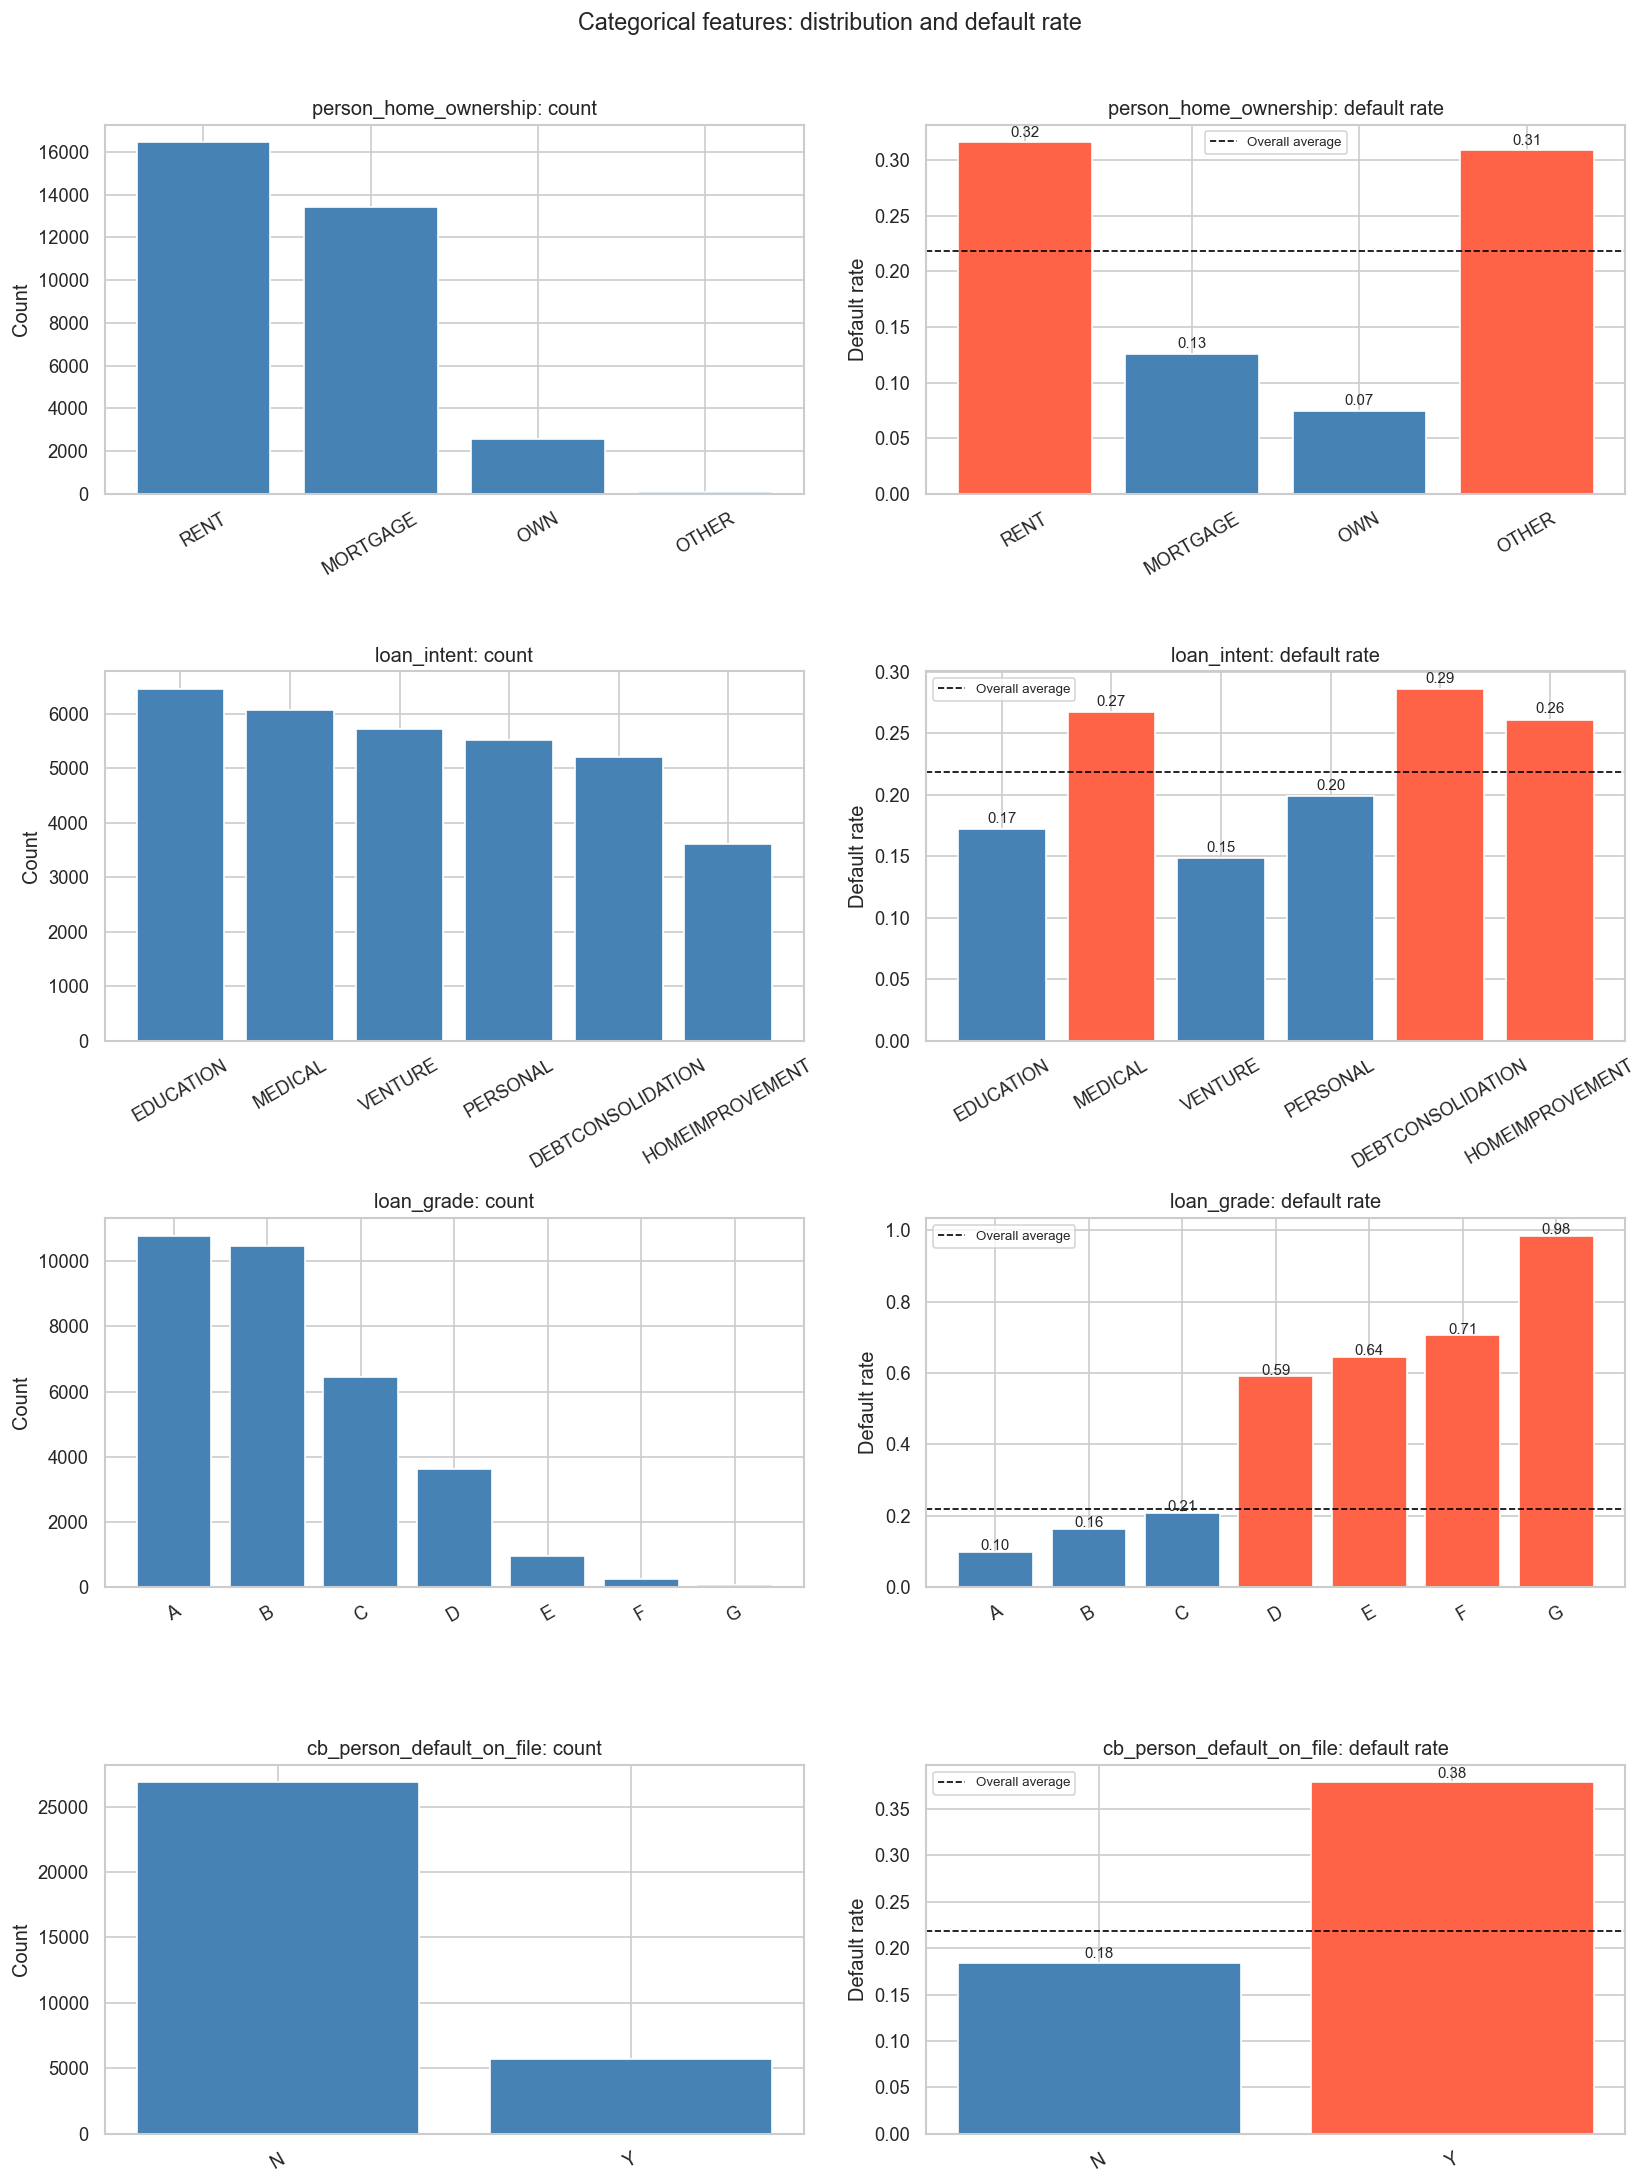

In [10]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    default_rate = df.groupby(col)['loan_status'].mean().reindex(counts.index)

    # Left: count distribution
    axes[i, 0].bar(counts.index, counts.values, color='steelblue')
    axes[i, 0].set_title(f'{col}: count')
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].tick_params(axis='x', rotation=30)

    # Right: default rate per category
    bar_colors = ['tomato' if v > df['loan_status'].mean() else 'steelblue'
                  for v in default_rate.values]
    axes[i, 1].bar(default_rate.index, default_rate.values, color=bar_colors)
    axes[i, 1].axhline(df['loan_status'].mean(), color='black',
                       linestyle='--', linewidth=1, label='Overall average')
    axes[i, 1].set_title(f'{col}: default rate')
    axes[i, 1].set_ylabel('Default rate')
    axes[i, 1].tick_params(axis='x', rotation=30)
    axes[i, 1].legend(fontsize=8)
    for j, (cat, val) in enumerate(default_rate.items()):
        axes[i, 1].text(j, val + 0.005, f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('Categorical features: distribution and default rate', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

A few observations stand out:

- **`loan_grade`** is by far the strongest predictor: default rates range from 10% (grade A) to 98% (grade G). The signal is almost monotonic.
- **`person_home_ownership`**: renters default at 31.6%, almost three times more than homeowners (7.5%). This variable acts as a proxy for financial stability.
- **`loan_intent`**: debt consolidation and medical loans have the highest default rates (28.6% and 26.7%). Education and venture loans are safer.
- **`cb_person_default_on_file`**: borrowers with a prior default on file default at 37.8% vs 18.4% for others, a strong historical signal.

## 6. Bivariate analysis: numerical features vs default

We compare the distribution of each numerical variable between defaulters and non-defaulters using overlapping histograms and boxplots. A clear separation between the two groups indicates a useful feature.

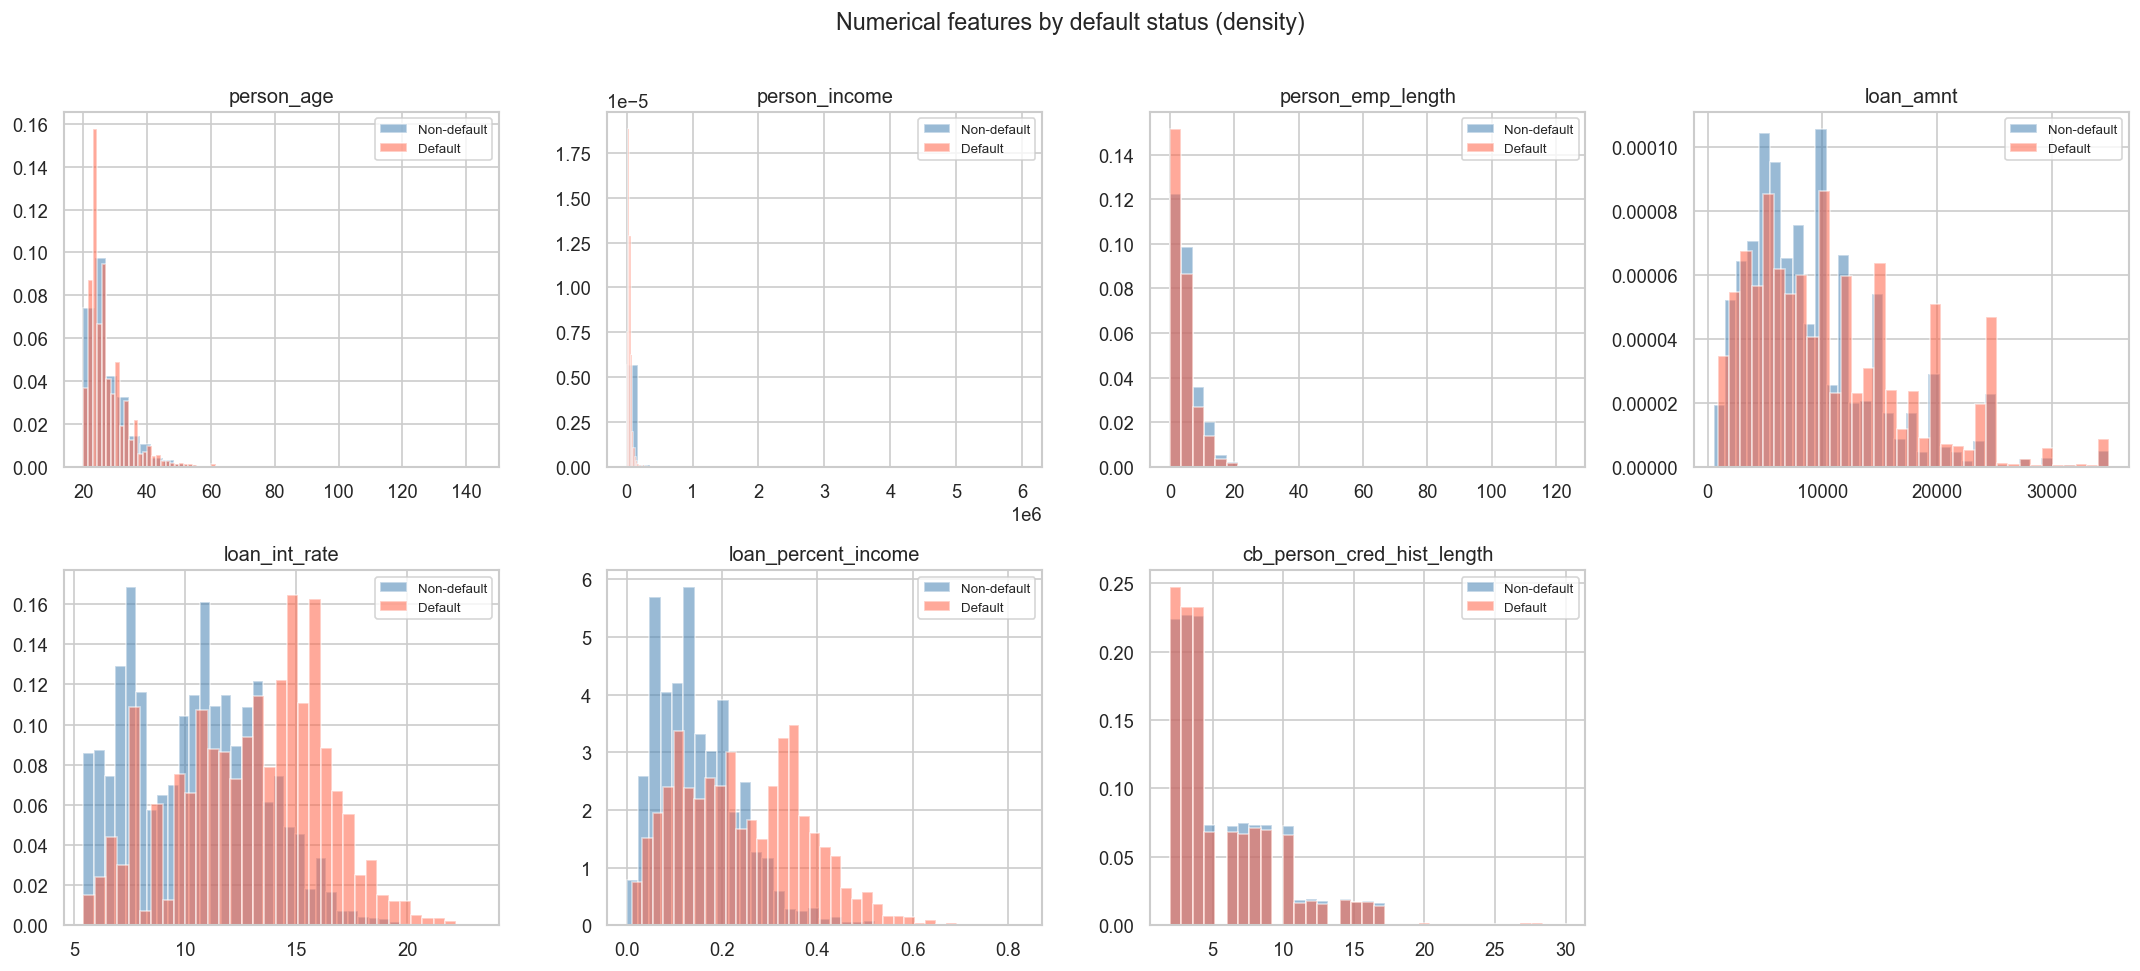

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

palette = {0: 'steelblue', 1: 'tomato'}
labels  = {0: 'Non-default', 1: 'Default'}

for ax, col in zip(axes, num_cols):
    for status in [0, 1]:
        data = df.loc[df['loan_status'] == status, col].dropna()
        ax.hist(data, bins=35, alpha=0.55,
                color=palette[status], label=labels[status],
                density=True, edgecolor='white')
    ax.set_title(col)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Numerical features by default status (density)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data_to_plot = [df.loc[df['loan_status'] == s, col].dropna().values
                    for s in [0, 1]]
    bp = ax.boxplot(data_to_plot, patch_artist=True,
                    labels=['Non-default', 'Default'])
    for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col)

axes[-1].set_visible(False)
plt.suptitle('Numerical features by default status (boxplot)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Mean comparison table
summary = df.groupby('loan_status')[num_cols].mean().T.round(2)
summary.columns = ['Non-default', 'Default']
summary['Difference (%)'] = ((summary['Default'] - summary['Non-default'])
                              / summary['Non-default'] * 100).round(1)
print(summary.to_string())

Key observations:

- **`loan_percent_income`** shows the clearest separation: defaulters carry a much higher debt-to-income ratio on average.
- **`loan_int_rate`** is also strongly discriminating, consistent with its near-perfect correlation with `loan_grade`.
- **`person_income`** is lower for defaulters, as expected.
- **`person_age`** and **`cb_person_cred_hist_length`** show little separation, though both are correlated with each other (older borrowers have longer histories).

## 7. Correlation analysis

We look at pairwise correlations between numerical features to anticipate multicollinearity issues in the models. Two pairs stand out: `loan_grade` / `loan_int_rate` (0.89) and `person_age` / `cb_person_cred_hist_length` (0.88). These will affect how linear models assign coefficients.

In [ ]:
# Ordinal encode loan_grade for correlation computation
df_corr = df.copy()
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_corr['loan_grade'] = df_corr['loan_grade'].map(grade_map)
df_corr['cb_person_default_on_file'] = df_corr['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

corr_cols = num_cols + ['loan_grade', 'cb_person_default_on_file', 'loan_status']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=.4, annot_kws={'size': 8},
    cbar_kws={'shrink': .8}
)
plt.title('Correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Top correlations with the target
target_corr = corr_matrix['loan_status'].drop('loan_status').sort_values(key=abs, ascending=False)
print('Correlation with loan_status (sorted by absolute value):')
print(target_corr.round(3).to_string())

## Summary

The main takeaways from this EDA:

- **`loan_grade`** and **`loan_int_rate`** are the strongest predictors of default, but their near-perfect correlation (0.89) will create instability in linear models.
- **`loan_percent_income`** is the most discriminating continuous variable.
- **`person_home_ownership_RENT`** (once one-hot encoded) will be an important feature for tree-based models, as renters default at 3x the rate of owners.
- Missing values in `loan_int_rate` (9.6%) and `person_emp_length` (2.7%) should be treated with indicator variables to preserve any predictive signal carried by the absence of data.
- A handful of outliers in `person_age` and `person_emp_length` are clearly erroneous and should be removed before modeling.